# R34 — R31 + Dual Aggregation Cascade for Referable Glaucoma

**Diagnosis from R33**: BayesSearchCV added risk with no benefit; reduced bagging (15 vs 25) was the primary cause of regression; coarser grid and AUC scorer misalignment were secondary factors.

**R34 = R31 (proven best) + one targeted enhancement: dual aggregation**

## What stays the same (from R31):
- **No BayesSearchCV** — R28 hyperparameters used directly (proven optimal)
- **25-bag ensemble** (5 seeds × 5 arch variants) — full ensemble restored
- **MLP_MAX_ITER = 400** — full convergence budget
- **THRESHOLD_GRID = 301** — fine resolution restored
- **Same PCA → MI → metadata → OD pipeline** as R28/R31

## What's new (from R33):
- **Dual aggregation**: At Stage 2, try BOTH:
  1. **Bilateral counting** (original): per-eye threshold → count ≥2 positive → referable
  2. **Mean proba**: patient score = mean of eye probabilities → threshold → referable
  - Keep whichever produces higher val F1 per encoder

This is the minimal, safe change that could unlock marginal gains without the risks that caused R33 to regress.

In [1]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 1 — Imports
# ═══════════════════════════════════════════════════════════════════════
from __future__ import annotations
import json, time, warnings, ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.collections import LineCollection

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, balanced_accuracy_score,
    confusion_matrix, classification_report, roc_curve,
)

import sys
sys.path.insert(0, str(Path.cwd() / 'src'))
from retina_embeddings_dataset import load_retina_embeddings_dataset

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
print('R34 imports OK')

R34 imports OK


In [2]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 2 — Configuration (identical to R31 except output dir)
# ═══════════════════════════════════════════════════════════════════════

DATASET_NAME = 'brset'
TASK         = 'increased_cup_disc'   # per-eye label used by Stage 1
RANDOM_SEED  = 42

from multiprocessing import cpu_count
CPU_COUNT = cpu_count()

# ─── Paths ────────────────────────────────────────────────────────
BASE_DIR     = Path.cwd()
FE_DIR       = BASE_DIR / 'artifacts' / 'brset_eda_fe'
EMBED_DIR    = BASE_DIR / 'data' / 'brset_embeddings'
LABELS_PATH  = EMBED_DIR / 'brset_labels' / 'labels_brset.csv'
RESULTS_DIR  = BASE_DIR / 'results' / 'brset_r34_dual_agg_cascade_referable_glaucoma'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# R28 saved hyperparameters (used directly, no BayesSearchCV)
R28_DIR = BASE_DIR / 'results' / 'brset_r28_fe_experiment' / 'r28_per_encoder'

# Previous runs for comparison
R31_DIR_CMP = BASE_DIR / 'results' / 'brset_r31_cascade_referable_glaucoma' / 'r31_per_encoder'
R33_DIR_CMP = BASE_DIR / 'results' / 'brset_r33_auc_cascade_referable_glaucoma' / 'r33_per_encoder'

# ─── Pipeline parameters (IDENTICAL to R31 — proven best) ─────────
PCA_COMPONENTS       = 384
MI_SELECTION         = True
MI_PERCENTILE_THRESH = 0.15
MI_MIN_COMPONENTS    = 128

MLP_MAX_ITER   = 400          # ← R31 value (restored from R33's 300)
MLP_PATIENCE   = 30

BAG_SEEDS           = [42, 123, 314, 555, 789]   # ← R31: 5 seeds (restored from R33's 3)
N_BAG_ARCH_VARIANTS = 5
N_BAGS = len(BAG_SEEDS) * N_BAG_ARCH_VARIANTS    # 25 (restored from R33's 15)

THRESHOLD_GRID  = 301         # ← R31 value (restored from R33's 151)
THRESHOLD_FLOOR = 0.05

# ─── Clinical metadata (same 5 cols as R28/R31) ──────────────────
METADATA_COLS = {
    'age':      'numeric',
    'sex':      'passthrough',
    'diabetes': 'binary_yn',
    'exam_eye': 'binary',
    'camera':   'camera',
}

# ─── optic_disc masking (same as R28/R31) ────────────────────────
OD_P_MASK_BASE    = 0.50
OD_P_MASK_RANGE   = (0.35, 0.70)
OD_CORRUPT        = 0.10
OD_FEATURE_WEIGHT = 0.50
OD_MISS_WEIGHT    = 0.50
OD_TEST_P_MASK    = 0.25

# ─── Bilateral / referable threshold ─────────────────────────────
BILATERAL_MIN_EYES = 2   # ≥ 2 positive images → referable

print(f'R28 hyper dir:   {R28_DIR}')
print(f'Results dir:     {RESULTS_DIR}')
print(f'Stage 1 task:    {TASK} (per-eye)')
print(f'Stage 2 rule:    ≥{BILATERAL_MIN_EYES} positive eyes → referable (PATIENT-LEVEL)')
print(f'  NEW in R34:    Dual aggregation (bilateral counting + mean_proba)')
print(f'PCA: {PCA_COMPONENTS} | MI: drop <{MI_PERCENTILE_THRESH:.0%} | min {MI_MIN_COMPONENTS}')
print(f'Bagging: {len(BAG_SEEDS)} seeds × {N_BAG_ARCH_VARIANTS} variants = {N_BAGS}')
print(f'MLP: max_iter={MLP_MAX_ITER}, patience={MLP_PATIENCE}')
print(f'OD masking: base={OD_P_MASK_BASE:.0%}, range={OD_P_MASK_RANGE}, corrupt={OD_CORRUPT:.0%}')
print(f'Threshold grid: {THRESHOLD_GRID} points')

R28 hyper dir:   c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r28_fe_experiment\r28_per_encoder
Results dir:     c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r34_dual_agg_cascade_referable_glaucoma
Stage 1 task:    increased_cup_disc (per-eye)
Stage 2 rule:    ≥2 positive eyes → referable (PATIENT-LEVEL)
  NEW in R34:    Dual aggregation (bilateral counting + mean_proba)
PCA: 384 | MI: drop <15% | min 128
Bagging: 5 seeds × 5 variants = 25
MLP: max_iter=400, patience=30
OD masking: base=50%, range=(0.35, 0.7), corrupt=10%
Threshold grid: 301 points


In [3]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 3 — Load Data + FE Artifacts
# ═══════════════════════════════════════════════════════════════════════

splits = pd.read_csv(FE_DIR / 'splits_patient.csv')
splits['patient_id'] = splits['patient_id'].astype(str)

train_pids = set(splits[splits['split'] == 'train']['patient_id'])
val_pids   = set(splits[splits['split'] == 'val']['patient_id'])
test_pids  = set(splits[splits['split'] == 'test']['patient_id'])

assert len(train_pids & val_pids)  == 0, 'Train/val patient leakage!'
assert len(train_pids & test_pids) == 0, 'Train/test patient leakage!'
assert len(val_pids   & test_pids) == 0, 'Val/test patient leakage!'

labels_raw = pd.read_csv(LABELS_PATH)
labels_raw['patient_id'] = labels_raw['patient_id'].astype(str)
labels_raw = labels_raw.rename(columns={'patient_age': 'age', 'patient_sex': 'sex'})

embedding_files = sorted(EMBED_DIR.glob('Embeddings_*.csv'))

def build_referable_labels(df, task_col, min_eyes):
    """Return Series: patient_id → 1 (referable) or 0."""
    pos_count = df[df[task_col] == 1].groupby('patient_id')[task_col].count()
    all_pids = df['patient_id'].unique()
    result = pd.Series(0, index=all_pids, name='referable_glaucoma')
    referable = pos_count[pos_count >= min_eyes].index
    result.loc[result.index.isin(referable)] = 1
    return result

# Preview patient distribution
_preview_df = labels_raw.dropna(subset=[TASK]).copy()
_preview_df['patient_id'] = _preview_df['patient_id'].astype(str)
_ref = build_referable_labels(_preview_df, TASK, BILATERAL_MIN_EYES)
_ref_train = _ref[_ref.index.isin(train_pids)]
_ref_val   = _ref[_ref.index.isin(val_pids)]
_ref_test  = _ref[_ref.index.isin(test_pids)]

print(f'Patient split:   {len(train_pids)} train / {len(val_pids)} val / {len(test_pids)} test')
print(f'Embedding files: {len(embedding_files)}')
print(f'\nReferable glaucoma (≥{BILATERAL_MIN_EYES} eyes with {TASK}=1):')
print(f'  Train: {_ref_train.sum():>4}/{len(_ref_train)} ({_ref_train.mean():.1%})')
print(f'  Val:   {_ref_val.sum():>4}/{len(_ref_val)} ({_ref_val.mean():.1%})')
print(f'  Test:  {_ref_test.sum():>4}/{len(_ref_test)} ({_ref_test.mean():.1%})')

# ─── Load R28 hyperparameters for all encoders ────────────────────
r28_hypers = {}
for d in sorted(R28_DIR.iterdir()):
    hp_file = d / 'hyperparameters.json'
    if hp_file.exists():
        with open(hp_file) as f:
            hp = json.load(f)
        r28_hypers[hp['embedding']] = hp
        print(f'  R28 hypers loaded: {hp["embedding"]}  '
              f'arch={hp["architecture"]}  α={hp["alpha"]:.4f}  '
              f'lr={hp["lr"]:.6f}  w={hp["pos_weight"]:.2f}  '
              f'agg={hp["best_agg"]}')

print(f'\nLoaded R28 hyperparameters for {len(r28_hypers)} encoders')

Patient split:   5796 train / 1023 val / 1705 test
Embedding files: 7

Referable glaucoma (≥2 eyes with increased_cup_disc=1):
  Train:  789/5796 (13.6%)
  Val:    157/1023 (15.3%)
  Test:   229/1705 (13.4%)
  R28 hypers loaded: convnextv2_base_  arch=(128,)  α=1.0000  lr=0.000100  w=4.07  agg=max
  R28 hypers loaded: dinov3_convnext_base  arch=(128,)  α=1.0000  lr=0.000358  w=2.46  agg=mean
  R28 hypers loaded: dinov3_vitb16  arch=(128,)  α=1.0000  lr=0.000301  w=2.45  agg=noisy_or
  R28 hypers loaded: RETFound_dinov2_shanghai  arch=(512,)  α=1.0000  lr=0.000100  w=2.91  agg=max
  R28 hypers loaded: RETFound_mae_natureCFP  arch=(512,)  α=0.0010  lr=0.000210  w=3.37  agg=max
  R28 hypers loaded: RETFound_mae_shanghai  arch=(256,)  α=0.0014  lr=0.002000  w=1.00  agg=noisy_or
  R28 hypers loaded: vit_base_  arch=(256,)  α=0.0010  lr=0.002000  w=2.62  agg=max

Loaded R28 hyperparameters for 7 encoders


In [4]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 4 — Helper Functions (R31 base + dual aggregation from R33)
# ═══════════════════════════════════════════════════════════════════════

def short_name(path):
    stem = Path(path).stem
    for s in ['Embeddings_brset_', 'Embeddings_']:
        stem = stem.replace(s, '')
    return stem


def make_sample_weights(y, pos_class_weight=1.0):
    y = np.asarray(y)
    w = np.where(y == 1, float(pos_class_weight), 1.0).astype(np.float32)
    mean_w = w.mean()
    if mean_w > 0:
        w /= mean_w
    return w


def mi_select_features(X_train, y_train, X_others,
                       percentile_thresh=0.15, min_components=128,
                       random_state=42):
    mi_scores = mutual_info_classif(
        X_train, y_train, discrete_features=False,
        n_neighbors=5, random_state=random_state,
    )
    threshold = np.percentile(mi_scores, percentile_thresh * 100)
    mask = mi_scores >= threshold
    if mask.sum() < min_components:
        top_k = np.argsort(mi_scores)[-min_components:]
        mask = np.zeros(len(mi_scores), dtype=bool)
        mask[top_k] = True
    X_train_sel = X_train[:, mask]
    X_others_sel = [X[:, mask] for X in X_others]
    return X_train_sel, X_others_sel, mask, mi_scores


def encode_metadata(df, metadata_cols, fit_stats=None):
    if fit_stats is None:
        fit_stats = {}
    meta_parts = []
    for col, dtype in metadata_cols.items():
        if col not in df.columns:
            print(f'    WARNING: metadata col {col!r} not found, skipping')
            continue
        vals = df[col].copy()
        if dtype == 'numeric':
            vals = pd.to_numeric(vals, errors='coerce')
            if 'median_' + col not in fit_stats:
                fit_stats['median_' + col] = float(vals.median())
            vals = vals.fillna(fit_stats['median_' + col])
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'binary':
            vals = pd.to_numeric(vals, errors='coerce').fillna(1)
            vals = (vals - 1).clip(0, 1)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'passthrough':
            vals = pd.to_numeric(vals, errors='coerce').fillna(0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'binary_yn':
            vals = vals.astype(str).str.lower().map({'yes': 1.0, 'no': 0.0}).fillna(0.0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'camera':
            vals = vals.astype(str).map({'Canon CR': 0.0, 'NIKON NF5050': 1.0}).fillna(0.0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
    if not meta_parts:
        return np.zeros((len(df), 0), dtype=np.float32), fit_stats
    return np.hstack(meta_parts), fit_stats


def make_wider(arch, factor=1.5):
    return tuple(max(64, int(x * factor)) for x in arch)
def make_deeper(arch):
    return arch + (max(64, arch[-1] // 2),)
def make_narrower(arch, factor=0.67):
    return tuple(max(64, int(x * factor)) for x in arch)
def make_shallower(arch):
    if len(arch) > 1: return arch[:-1]
    return (max(64, arch[0] // 2),)


# ─── optic_disc masking (same as R28/R31) ─────────────────────────
def _bin_od(series):
    return (pd.to_numeric(series, errors='coerce') == 2).astype(np.float32).to_numpy()

def _mask_od(od_series, p_mask, rng, p_corrupt=0.0):
    od = _bin_od(od_series)
    if p_mask >= 1.0:
        miss = np.ones(len(od), dtype=bool)
    elif p_mask > 0:
        miss = rng.random(len(od)) < p_mask
    else:
        miss = np.zeros(len(od), dtype=bool)
    od_m = od.copy()
    od_m[miss] = 0.0
    if p_corrupt and p_corrupt > 0:
        corrupt = (~miss) & (rng.random(len(od)) < p_corrupt)
        od_m[corrupt] = 1.0 - od_m[corrupt]
    return od_m.reshape(-1, 1), miss.astype(np.float32).reshape(-1, 1)

def _apply_od_weights(X_s, od_w, miss_w):
    if X_s.shape[1] < 2: return X_s
    if od_w != 1.0: X_s[:, -2] *= od_w
    if miss_w != 1.0: X_s[:, -1] *= miss_w
    return X_s


# ─── Bilateral cascade logic (from R31) ───────────────────────────
def bilateral_patient_predictions(pids, proba, threshold, min_eyes=2):
    df = pd.DataFrame({
        'patient_id': pids,
        'proba': proba,
        'pred_pos': (proba >= threshold).astype(int),
    })
    agg = df.groupby('patient_id').agg(
        n_positive=('pred_pos', 'sum'),
        n_images=('pred_pos', 'count'),
        max_proba=('proba', 'max'),
        mean_proba=('proba', 'mean'),
    )
    agg['referable_pred'] = (agg['n_positive'] >= min_eyes).astype(int)
    return agg


def sweep_bilateral_threshold(pids, proba, y_referable_patient,
                              min_eyes=2, grid_size=301, floor=0.05):
    """Original R31 bilateral counting sweep (kept for artifact saving)."""
    thresholds = np.linspace(floor, 0.99, grid_size)
    best_f1, best_t = 0.0, 0.5
    all_res = []
    for t in thresholds:
        agg = bilateral_patient_predictions(pids, proba, t, min_eyes)
        com = agg.index.intersection(y_referable_patient.index)
        if len(com) == 0: continue
        yt = y_referable_patient.loc[com].values
        yh = agg.loc[com, 'referable_pred'].values
        f1 = f1_score(yt, yh, zero_division=0) if yh.sum() > 0 else 0.0
        prec = precision_score(yt, yh, zero_division=0)
        rec  = recall_score(yt, yh, zero_division=0)
        all_res.append({'threshold': t, 'f1': f1, 'precision': prec, 'recall': rec,
                        'n_predicted_pos': int(yh.sum())})
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1, pd.DataFrame(all_res)


# ─── NEW in R34: Dual aggregation sweep ───────────────────────────
def sweep_bilateral_threshold_dual(pids, proba, y_referable_patient,
                                   min_eyes=2, grid_size=301, floor=0.05):
    """
    R34 enhancement: Sweep bilateral threshold using BOTH counting
    and mean_proba methods. Returns the best across both approaches.
    """
    thresholds = np.linspace(floor, 0.99, grid_size)
    best_f1, best_t, best_method = 0.0, 0.5, 'bilateral'
    all_res = []

    # Method 1: Bilateral counting (original R31)
    for t in thresholds:
        agg = bilateral_patient_predictions(pids, proba, t, min_eyes)
        com = agg.index.intersection(y_referable_patient.index)
        if len(com) == 0: continue
        yt = y_referable_patient.loc[com].values
        yh = agg.loc[com, 'referable_pred'].values
        f1 = f1_score(yt, yh, zero_division=0) if yh.sum() > 0 else 0.0
        prec = precision_score(yt, yh, zero_division=0)
        rec  = recall_score(yt, yh, zero_division=0)
        all_res.append({'method': 'bilateral', 'threshold': t, 'f1': f1,
                        'precision': prec, 'recall': rec, 'n_predicted_pos': int(yh.sum())})
        if f1 > best_f1:
            best_f1, best_t, best_method = f1, t, 'bilateral'

    # Method 2: Mean proba — patient score = mean of eye probabilities
    df_p = pd.DataFrame({'patient_id': pids, 'proba': proba})
    mean_agg = df_p.groupby('patient_id')['proba'].mean()
    for t in thresholds:
        yh_mean = (mean_agg >= t).astype(int)
        com = mean_agg.index.intersection(y_referable_patient.index)
        if len(com) == 0: continue
        yt = y_referable_patient.loc[com].values
        yh = yh_mean.loc[com].values
        f1 = f1_score(yt, yh, zero_division=0) if yh.sum() > 0 else 0.0
        prec = precision_score(yt, yh, zero_division=0)
        rec  = recall_score(yt, yh, zero_division=0)
        all_res.append({'method': 'mean_proba', 'threshold': t, 'f1': f1,
                        'precision': prec, 'recall': rec, 'n_predicted_pos': int(yh.sum())})
        if f1 > best_f1:
            best_f1, best_t, best_method = f1, t, 'mean_proba'

    return best_t, best_f1, best_method, pd.DataFrame(all_res)


# ─── Plotting ─────────────────────────────────────────────────────
def plot_confusion_matrix(cm, title, save_path=None, show=True):
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    cm_plot = np.ma.masked_where(cm <= 0, cm)
    vmax = int(cm.max()) if cm.size else 1
    norm = LogNorm(vmin=1, vmax=max(1, vmax))
    im = ax.imshow(cm_plot, cmap='viridis', interpolation='nearest', norm=norm)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('Count (log)', fontsize=9)
    ax.set_title(title, fontsize=11, pad=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks(range(cm.shape[1])); ax.set_yticks(range(cm.shape[0]))
    thresh = cm.max() / 2.0
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f'{val}', ha='center', va='center',
                color='white' if val > thresh else 'black', fontsize=10, fontweight='bold')
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=160, bbox_inches='tight')
    if show: plt.show()
    else: plt.close(fig)


def plot_roc_curve(fpr, tpr, auc_val, title, save_path=None, show=True):
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    points = np.array([fpr, tpr]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap='plasma', norm=Normalize(0, 1))
    lc.set_array(fpr); lc.set_linewidth(2.6)
    ax.add_collection(lc)
    ax.plot([0,1],[0,1],'--', color='#666', lw=1.2, label='Chance')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_title(f'{title}\nAUC = {auc_val:.3f}', fontsize=11, pad=12)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=9)
    fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04).set_label('FPR', fontsize=9)
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=160, bbox_inches='tight')
    if show: plt.show()
    else: plt.close(fig)


print(f'Helpers OK  (bilateral min eyes = {BILATERAL_MIN_EYES}, dual aggregation enabled)')

Helpers OK  (bilateral min eyes = 2, dual aggregation enabled)


## Per-Encoder Two-Stage Cascade (R34)

For each encoder:
1. **Load R28 hyperparameters** (skip BayesSearchCV entirely — proven optimal)
2. **Retrain 25 bagged MLPs** on `increased_cup_disc` with R28's optimal params
3. **Get per-image probabilities** (calibrated with IsotonicRegression)
4. **Dual aggregation sweep** on val (NEW in R34):
   - **Bilateral counting**: per-eye threshold → count ≥2 positive → referable (original R31)
   - **Mean proba**: patient score = mean of eye probabilities → threshold → referable
   - Keep whichever produces higher val F1
5. **Evaluate on test** with best bilateral threshold → patient-level metrics

════════════════════════════════════════════════════════════════════════════════
R34 — Two-Stage Cascade + Dual Aggregation
  Stage 1: Per-Eye MLP (R28 params, 25 bags)
  Stage 2: Bilateral Counting + Mean Proba (keep best)
════════════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════════════
[1/7] R34 — convnextv2_base_
  R28 hypers: arch=(128,) α=1.0000 lr=0.000100 bs=64 w=4.07
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (98.8% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Bagging] 25 models (R28 hypers, no search)
  Stage 1 done: 25 MLPs trained
  Per-image proba range: val=[0.001, 0.999]  test=[0.001, 0.999]
  ★ Stage 2: raw | bilateral | thr=0.432 | val_F1=0.7877
  TEST: F1=0.7445  Prec=0.6903  Rec=0.8079  AUC=0.9422  BalAcc=0.8758
  Val−Test gap: +0.0432
  Time: 377s (6.3 min)
               precision    recall  f1-score  

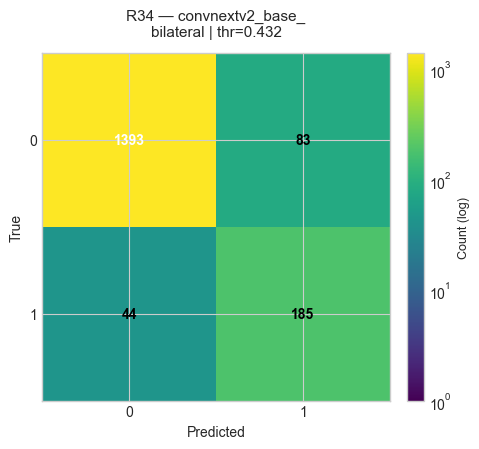

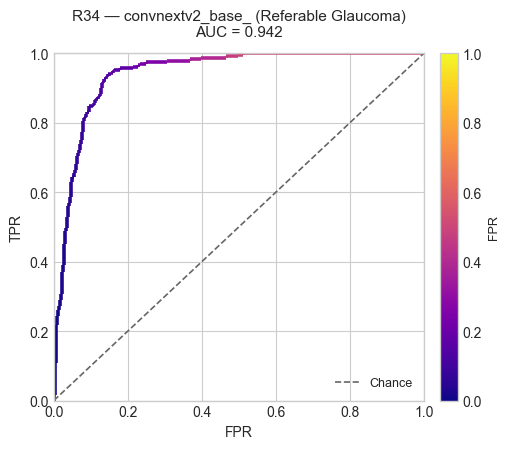


════════════════════════════════════════════════════════════════════════════════
[2/7] R34 — dinov3_convnext_base
  R28 hypers: arch=(128,) α=1.0000 lr=0.000358 bs=64 w=2.46
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (99.5% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Bagging] 25 models (R28 hypers, no search)
  Stage 1 done: 25 MLPs trained
  Per-image proba range: val=[0.001, 0.988]  test=[0.001, 0.999]
  ★ Stage 2: raw | bilateral | thr=0.429 | val_F1=0.8000
  TEST: F1=0.7640  Prec=0.7870  Rec=0.7424  AUC=0.9483  BalAcc=0.8556
  Val−Test gap: +0.0360
  Time: 420s (7.0 min)
               precision    recall  f1-score   support

Not Referable      0.960     0.969     0.965      1476
    Referable      0.787     0.742     0.764       229

     accuracy                          0.938      1705
    macro avg      0.874     0.856     0.864      1705
 weighted avg      0.937     0.938     0.938      1705



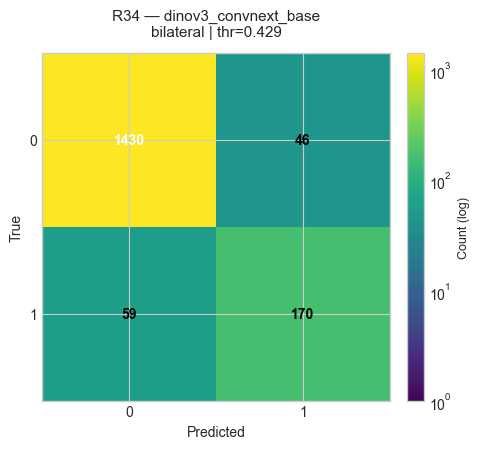

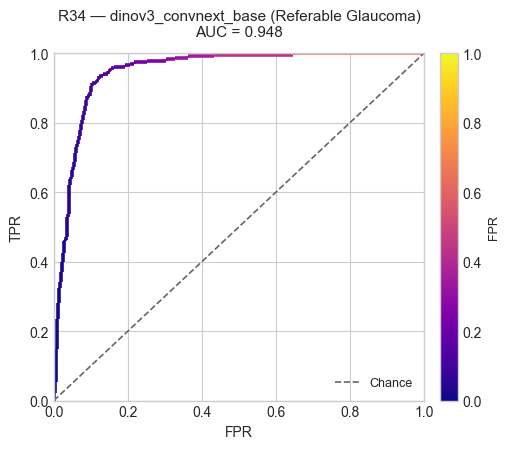


════════════════════════════════════════════════════════════════════════════════
[3/7] R34 — dinov3_vitb16
  R28 hypers: arch=(128,) α=1.0000 lr=0.000301 bs=256 w=2.45
════════════════════════════════════════════════════════════════════════════════
  PCA: 768→384 (98.7% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Bagging] 25 models (R28 hypers, no search)
  Stage 1 done: 25 MLPs trained
  Per-image proba range: val=[0.001, 0.999]  test=[0.001, 0.999]
  ★ Stage 2: raw | bilateral | thr=0.294 | val_F1=0.8444
  TEST: F1=0.8009  Prec=0.8117  Rec=0.7904  AUC=0.9486  BalAcc=0.8810
  Val−Test gap: +0.0436
  Time: 229s (3.8 min)
               precision    recall  f1-score   support

Not Referable      0.968     0.972     0.970      1476
    Referable      0.812     0.790     0.801       229

     accuracy                          0.947      1705
    macro avg      0.890     0.881     0.885      1705
 weighted avg      0.947     0.947     0.947      1705



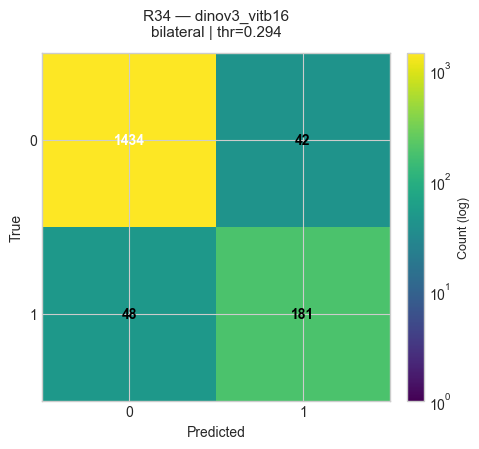

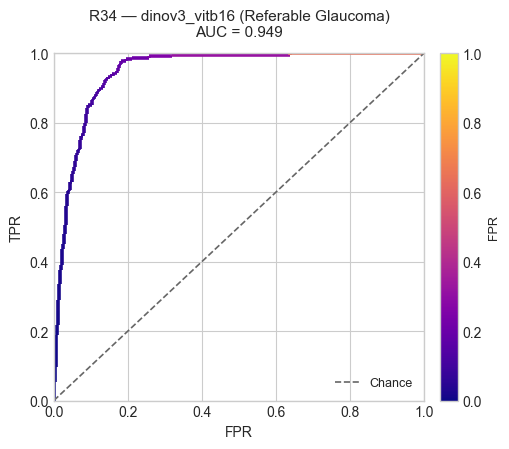


════════════════════════════════════════════════════════════════════════════════
[4/7] R34 — RETFound_dinov2_shanghai
  R28 hypers: arch=(512,) α=1.0000 lr=0.000100 bs=64 w=2.91
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (98.2% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Bagging] 25 models (R28 hypers, no search)
  Stage 1 done: 25 MLPs trained
  Per-image proba range: val=[0.001, 0.999]  test=[0.001, 0.999]
  ★ Stage 2: raw | bilateral | thr=0.301 | val_F1=0.7965
  TEST: F1=0.7435  Prec=0.6472  Rec=0.8734  AUC=0.9395  BalAcc=0.8998
  Val−Test gap: +0.0530
  Time: 1438s (24.0 min)
               precision    recall  f1-score   support

Not Referable      0.979     0.926     0.952      1476
    Referable      0.647     0.873     0.743       229

     accuracy                          0.919      1705
    macro avg      0.813     0.900     0.848      1705
 weighted avg      0.935     0.919     0.924      1705



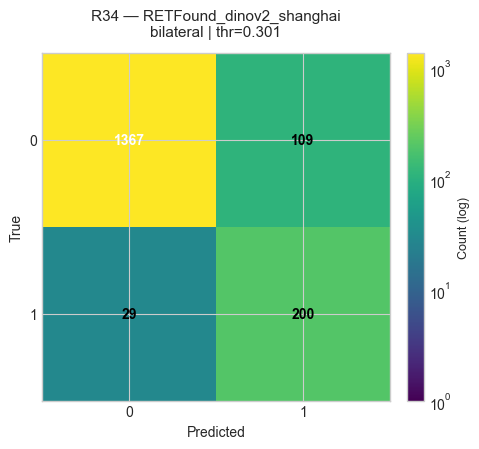

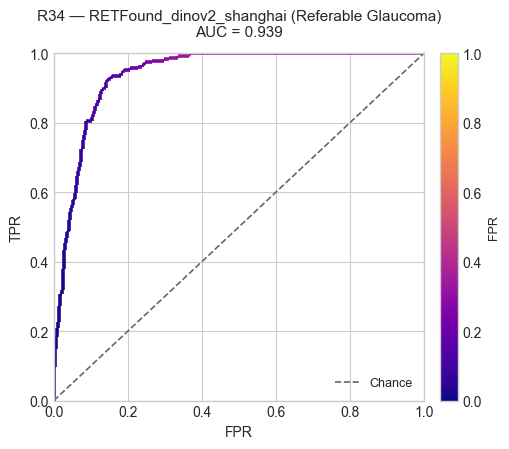


════════════════════════════════════════════════════════════════════════════════
[5/7] R34 — RETFound_mae_natureCFP
  R28 hypers: arch=(512,) α=0.0010 lr=0.000210 bs=64 w=3.37
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (99.3% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Bagging] 25 models (R28 hypers, no search)
  Stage 1 done: 25 MLPs trained
  Per-image proba range: val=[0.001, 0.999]  test=[0.001, 0.985]
  ★ Stage 2: raw | bilateral | thr=0.460 | val_F1=0.7677
  TEST: F1=0.7025  Prec=0.7202  Rec=0.6856  AUC=0.9240  BalAcc=0.8221
  Val−Test gap: +0.0652
  Time: 741s (12.3 min)
               precision    recall  f1-score   support

Not Referable      0.952     0.959     0.955      1476
    Referable      0.720     0.686     0.702       229

     accuracy                          0.922      1705
    macro avg      0.836     0.822     0.829      1705
 weighted avg      0.921     0.922     0.921      1705



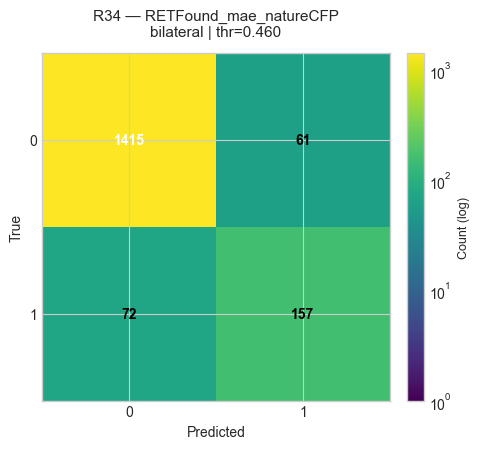

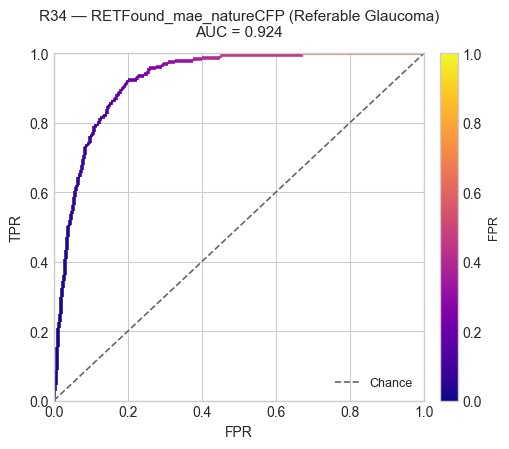


════════════════════════════════════════════════════════════════════════════════
[6/7] R34 — RETFound_mae_shanghai
  R28 hypers: arch=(256,) α=0.0014 lr=0.002000 bs=64 w=1.00
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (98.9% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Bagging] 25 models (R28 hypers, no search)


KeyboardInterrupt: 

In [5]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 6 — Per-Encoder Cascade Loop (R31 base + R34 dual aggregation)
# ═══════════════════════════════════════════════════════════════════════

R34_DIR = RESULTS_DIR / 'r34_per_encoder'
R34_DIR.mkdir(parents=True, exist_ok=True)

print('═' * 80)
print('R34 — Two-Stage Cascade + Dual Aggregation')
print('  Stage 1: Per-Eye MLP (R28 params, 25 bags)')
print('  Stage 2: Bilateral Counting + Mean Proba (keep best)')
print('═' * 80)

r34_results = []
t0_global = time.time()

for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)

    # ── Checkpoint: skip if results already exist ──────────────────
    chk_dir = R34_DIR / f'{emb_idx:02d}_{sname}'
    chk_hp  = chk_dir / 'hyperparameters.json'
    if chk_hp.exists():
        print(f'\n[{emb_idx+1}/{len(embedding_files)}] {sname} — CACHED, loading')
        with open(chk_hp) as _f:
            prev = json.load(_f)
        r34_results.append({
            'embedding': sname,
            'dim_raw': prev.get('emb_dim_raw', 0),
            'dim_pca': prev['pca_dim'],
            'dim_mi': prev['mi_selected'],
            'pca_var': prev['pca_var'],
            'r28_arch': prev['r28_architecture'],
            'r28_alpha': prev['r28_alpha'],
            'r28_lr': prev['r28_lr'],
            'r28_pos_weight': prev['r28_pos_weight'],
            'agg_method': prev.get('agg_method', 'bilateral'),
            'bilateral_threshold': prev['bilateral_threshold'],
            'proba_type': prev.get('proba_type', 'calibrated'),
            'val_referable_f1': prev['val_referable_f1'],
            'test_referable_f1': prev['test_referable_f1'],
            'test_referable_precision': prev['test_referable_precision'],
            'test_referable_recall': prev['test_referable_recall'],
            'test_referable_auc': prev['test_referable_auc'],
            'test_referable_bal_acc': prev['test_referable_bal_acc'],
            'n_test_patients': prev['n_test_patients'],
            'time_s': 0,
        })
        continue

    # ── Check R28 hyperparameters exist for this encoder ──────────
    if sname not in r28_hypers:
        print(f'\n[{emb_idx+1}/{len(embedding_files)}] {sname} — SKIPPED, no R28 hypers found')
        continue

    hp = r28_hypers[sname]
    barch  = ast.literal_eval(hp['architecture']) if isinstance(hp['architecture'], str) else tuple(hp['architecture'])
    balpha = hp['alpha']
    blr    = hp['lr']
    bbs    = hp['batch_size']
    bw     = hp['pos_weight']

    print(f'\n{"═"*80}')
    print(f'[{emb_idx+1}/{len(embedding_files)}] R34 — {sname}')
    print(f'  R28 hypers: arch={barch} α={balpha:.4f} lr={blr:.6f} bs={bbs} w={bw:.2f}')
    print(f'{"═"*80}')
    t0 = time.time()

    # ══════════════════════════════════════════════════════════════
    # STAGE 1: Train per-eye MLPs (R28 params, no search)
    # ══════════════════════════════════════════════════════════════

    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=LABELS_PATH,
    )
    df = ds.df.copy()
    df['patient_id'] = df['patient_id'].astype(str)

    b_train = df[df['patient_id'].isin(train_pids)].dropna(subset=[TASK]).copy()
    b_val   = df[df['patient_id'].isin(val_pids)].dropna(subset=[TASK]).copy()
    b_test  = df[df['patient_id'].isin(test_pids)].dropna(subset=[TASK]).copy()

    X_tr_emb = b_train[ds.feature_cols].to_numpy(dtype=np.float32)
    X_va_emb = b_val[ds.feature_cols].to_numpy(dtype=np.float32)
    X_te_emb = b_test[ds.feature_cols].to_numpy(dtype=np.float32)

    yb_train = b_train[TASK].to_numpy(dtype=int)
    yb_val   = b_val[TASK].to_numpy(dtype=int)
    yb_test  = b_test[TASK].to_numpy(dtype=int)

    pids_tr = b_train['patient_id'].to_numpy()
    pids_va = b_val['patient_id'].to_numpy()
    pids_te = b_test['patient_id'].to_numpy()

    emb_dim_raw = X_tr_emb.shape[1]

    # PCA
    nc = min(PCA_COMPONENTS, emb_dim_raw, X_tr_emb.shape[0])
    pca = PCA(n_components=nc, random_state=RANDOM_SEED)
    X_tr_pca = pca.fit_transform(X_tr_emb)
    X_va_pca = pca.transform(X_va_emb)
    X_te_pca = pca.transform(X_te_emb)
    var_exp = pca.explained_variance_ratio_.sum()
    print(f'  PCA: {emb_dim_raw}→{nc} ({var_exp:.1%} var)')

    # MI Selection
    if MI_SELECTION:
        X_tr_sel, (X_va_sel, X_te_sel), mi_mask, _ = mi_select_features(
            X_tr_pca, yb_train, [X_va_pca, X_te_pca],
            percentile_thresh=MI_PERCENTILE_THRESH,
            min_components=MI_MIN_COMPONENTS,
            random_state=RANDOM_SEED,
        )
        n_kept = mi_mask.sum()
        print(f'  MI: {nc}→{n_kept}')
    else:
        X_tr_sel, X_va_sel, X_te_sel = X_tr_pca, X_va_pca, X_te_pca
        n_kept = nc

    # Metadata
    X_tr_meta, ms = encode_metadata(b_train, METADATA_COLS)
    X_va_meta, _  = encode_metadata(b_val, METADATA_COLS, fit_stats=ms)
    X_te_meta, _  = encode_metadata(b_test, METADATA_COLS, fit_stats=ms)
    meta_dim = X_tr_meta.shape[1]

    # OD masking for training
    rng_hp = np.random.default_rng(RANDOM_SEED)
    od_tr, miss_tr = _mask_od(b_train['optic_disc'], OD_P_MASK_BASE, rng_hp, OD_CORRUPT)
    X_tr_full = np.hstack([X_tr_sel, X_tr_meta, od_tr, miss_tr])
    ndim = X_tr_full.shape[1]
    print(f'  Dims: {n_kept} PCA + {meta_dim} meta + 2 OD = {ndim}')

    # Scale
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_full)
    X_tr_s = _apply_od_weights(X_tr_s, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    # Pre-compute val/test with P25 OD masking
    rng_v = np.random.default_rng(RANDOM_SEED + 7000)
    rng_t = np.random.default_rng(RANDOM_SEED + 9999)
    od_v, miss_v = _mask_od(b_val['optic_disc'],  OD_TEST_P_MASK, rng_v)
    od_t, miss_t = _mask_od(b_test['optic_disc'], OD_TEST_P_MASK, rng_t)

    X_va_s = scaler.transform(np.hstack([X_va_sel, X_va_meta, od_v, miss_v]))
    X_te_s = scaler.transform(np.hstack([X_te_sel, X_te_meta, od_t, miss_t]))
    X_va_s = _apply_od_weights(X_va_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
    X_te_s = _apply_od_weights(X_te_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    # ── Bagging (25 MLPs, NO BayesSearchCV — same as R31) ─────────
    barchs = [barch, make_wider(barch), make_deeper(barch),
              make_narrower(barch), make_shallower(barch)]
    print(f'  [Bagging] {N_BAGS} models (R28 hypers, no search)')

    cal_p = {}
    cal_l = {}
    bag_va_proba = []
    bag_te_proba = []

    for s_idx, seed in enumerate(BAG_SEEDS):
        upids = np.unique(pids_tr)
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
        plm = b_train.groupby('patient_id')[TASK].max().to_dict()
        pl  = np.array([plm[p] for p in upids])
        ti, vi = next(sss.split(upids, pl))
        itr_pids = set(upids[ti])
        iva_pids = set(upids[vi])

        tr_m = np.isin(pids_tr, list(itr_pids))
        va_m = np.isin(pids_tr, list(iva_pids))

        rng_pm = np.random.default_rng(seed + 90000)
        pm_seed = float(rng_pm.uniform(OD_P_MASK_RANGE[0], OD_P_MASK_RANGE[1]))

        # Inner train
        rng_it = np.random.default_rng(seed + 10000)
        od_it, miss_it = _mask_od(
            b_train.iloc[np.where(tr_m)[0]]['optic_disc'], pm_seed, rng_it, OD_CORRUPT)
        X_it = scaler.transform(np.hstack([X_tr_sel[tr_m], X_tr_meta[tr_m], od_it, miss_it]))
        X_it = _apply_od_weights(X_it, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_it = yb_train[tr_m]

        # Inner val (for calibration)
        rng_iv = np.random.default_rng(seed + 20000)
        od_iv, miss_iv = _mask_od(
            b_train.iloc[np.where(va_m)[0]]['optic_disc'], pm_seed, rng_iv, OD_CORRUPT)
        X_iv = scaler.transform(np.hstack([X_tr_sel[va_m], X_tr_meta[va_m], od_iv, miss_iv]))
        X_iv = _apply_od_weights(X_iv, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_iv = yb_train[va_m]

        svp = []
        for a_idx, arch_v in enumerate(barchs):
            mlp = MLPClassifier(
                hidden_layer_sizes=arch_v, alpha=balpha,
                learning_rate='adaptive',
                learning_rate_init=blr, batch_size=bbs,
                max_iter=MLP_MAX_ITER, early_stopping=True,
                validation_fraction=0.15, n_iter_no_change=MLP_PATIENCE,
                random_state=seed + a_idx,
            )
            sw = make_sample_weights(y_it, bw)
            mlp.fit(X_it, y_it, sample_weight=sw)

            svp.append(mlp.predict_proba(X_iv)[:, 1])
            bag_va_proba.append(mlp.predict_proba(X_va_s)[:, 1])
            bag_te_proba.append(mlp.predict_proba(X_te_s)[:, 1])

        cal_p[seed] = np.mean(svp, axis=0)
        cal_l[seed] = y_iv

    # ── Calibration ───────────────────────────────────────────────
    cp = np.concatenate([cal_p[s] for s in BAG_SEEDS])
    cl = np.concatenate([cal_l[s] for s in BAG_SEEDS])
    iso = IsotonicRegression(y_min=0.001, y_max=0.999, out_of_bounds='clip')
    iso.fit(cp, cl)

    avg_va_raw = np.mean(bag_va_proba, axis=0)
    avg_te_raw = np.mean(bag_te_proba, axis=0)
    avg_va_cal = iso.predict(avg_va_raw)
    avg_te_cal = iso.predict(avg_te_raw)

    print(f'  Stage 1 done: {N_BAGS} MLPs trained')
    print(f'  Per-image proba range: val=[{avg_va_cal.min():.3f}, {avg_va_cal.max():.3f}]  '
          f'test=[{avg_te_cal.min():.3f}, {avg_te_cal.max():.3f}]')

    # ══════════════════════════════════════════════════════════════
    # STAGE 2: Dual Aggregation Sweep on Val (R34 enhancement)
    # ══════════════════════════════════════════════════════════════

    ref_val  = build_referable_labels(b_val, TASK, BILATERAL_MIN_EYES)
    ref_test = build_referable_labels(b_test, TASK, BILATERAL_MIN_EYES)

    # R34: Try both calibrated and raw, with dual aggregation each
    best_overall_f1 = 0.0
    best_overall_t  = 0.5
    best_pt = 'calibrated'
    best_agg_method = 'bilateral'

    for pt_name, va_proba, te_proba in [
        ('calibrated', avg_va_cal, avg_te_cal),
        ('raw', avg_va_raw, avg_te_raw),
    ]:
        # R34: Dual aggregation sweep (bilateral counting + mean_proba)
        bt, bf1, bmethod, sweep_df = sweep_bilateral_threshold_dual(
            pids_va, va_proba, ref_val,
            min_eyes=BILATERAL_MIN_EYES,
            grid_size=THRESHOLD_GRID,
            floor=THRESHOLD_FLOOR,
        )
        if bf1 > best_overall_f1:
            best_overall_f1 = bf1
            best_overall_t  = bt
            best_pt = pt_name
            best_agg_method = bmethod

    print(f'  ★ Stage 2: {best_pt} | {best_agg_method} | thr={best_overall_t:.3f} | val_F1={best_overall_f1:.4f}')

    # ── Evaluate on TEST ──────────────────────────────────────────
    te_proba_use = avg_te_cal if best_pt == 'calibrated' else avg_te_raw
    va_proba_use = avg_va_cal if best_pt == 'calibrated' else avg_va_raw

    # R34: Apply the winning aggregation method
    if best_agg_method == 'mean_proba':
        df_te_p = pd.DataFrame({'patient_id': pids_te, 'proba': te_proba_use})
        mean_te = df_te_p.groupby('patient_id')['proba'].mean()
        com = mean_te.index.intersection(ref_test.index)
        yt = ref_test.loc[com].values
        yh = (mean_te.loc[com] >= best_overall_t).astype(int).values
        yp = mean_te.loc[com].values
        # Also compute bilateral agg for artifact saving
        test_agg = bilateral_patient_predictions(pids_te, te_proba_use, best_overall_t, BILATERAL_MIN_EYES)
    else:
        test_agg = bilateral_patient_predictions(pids_te, te_proba_use, best_overall_t, BILATERAL_MIN_EYES)
        com = test_agg.index.intersection(ref_test.index)
        yt = ref_test.loc[com].values
        yh = test_agg.loc[com, 'referable_pred'].values
        yp = test_agg.loc[com, 'max_proba'].values

    test_f1   = float(f1_score(yt, yh, zero_division=0))
    test_prec = float(precision_score(yt, yh, zero_division=0))
    test_rec  = float(recall_score(yt, yh, zero_division=0))
    test_auc  = float(roc_auc_score(yt, yp)) if len(np.unique(yt)) > 1 else 0.0
    test_ba   = float(balanced_accuracy_score(yt, yh))

    elapsed = time.time() - t0

    print(f'  TEST: F1={test_f1:.4f}  Prec={test_prec:.4f}  Rec={test_rec:.4f}  '
          f'AUC={test_auc:.4f}  BalAcc={test_ba:.4f}')
    print(f'  Val−Test gap: {best_overall_f1 - test_f1:+.4f}')
    print(f'  Time: {elapsed:.0f}s ({elapsed/60:.1f} min)')

    # ── Save artifacts ────────────────────────────────────────────
    out_dir = R34_DIR / f'{emb_idx:02d}_{sname}'
    out_dir.mkdir(parents=True, exist_ok=True)

    cm = confusion_matrix(yt, yh)
    rep = classification_report(yt, yh, digits=3,
                                target_names=['Not Referable', 'Referable'])
    print(rep)

    pd.DataFrame(cm).to_csv(out_dir / 'confusion_matrix.csv', index=False)
    (out_dir / 'classification_report.txt').write_text(rep, encoding='utf-8')

    fpr, tpr, _ = roc_curve(yt, yp)
    pd.DataFrame({'fpr': fpr, 'tpr': tpr}).to_csv(out_dir / 'roc_curve.csv', index=False)

    # Patient predictions — always save bilateral agg for analysis
    if best_agg_method == 'mean_proba':
        # For mean_proba, also need bilateral agg for n_positive_eyes column
        test_agg_save = bilateral_patient_predictions(pids_te, te_proba_use, best_overall_t, BILATERAL_MIN_EYES)
        com_save = test_agg_save.index.intersection(ref_test.index)
        pd.DataFrame({
            'patient_id': com,
            'y_true_referable': yt,
            'y_pred_referable': yh,
            'mean_proba': yp,
            'max_proba': test_agg_save.loc[com, 'max_proba'].values,
            'n_positive_eyes': test_agg_save.loc[com, 'n_positive'].values,
            'n_images': test_agg_save.loc[com, 'n_images'].values,
        }).to_csv(out_dir / 'patient_predictions.csv', index=False)
    else:
        pd.DataFrame({
            'patient_id': com,
            'y_true_referable': yt,
            'y_pred_referable': yh,
            'max_proba': yp,
            'n_positive_eyes': test_agg.loc[com, 'n_positive'].values,
            'n_images': test_agg.loc[com, 'n_images'].values,
        }).to_csv(out_dir / 'patient_predictions.csv', index=False)

    pd.DataFrame({
        'image_id': b_test['image_id'].values,
        'patient_id': pids_te,
        'y_true_eye': yb_test,
        'proba_calibrated': avg_te_cal,
        'proba_raw': avg_te_raw,
        'pred_positive_eye': (te_proba_use >= best_overall_t).astype(int),
    }).to_csv(out_dir / 'image_predictions.csv', index=False)

    # Save full dual sweep for analysis
    _, _, _, sweep_final = sweep_bilateral_threshold_dual(
        pids_va, va_proba_use, ref_val,
        min_eyes=BILATERAL_MIN_EYES, grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR)
    sweep_final.to_csv(out_dir / 'bilateral_threshold_sweep.csv', index=False)

    hp_save = {
        'track': 'R34', 'embedding': sname,
        'r28_architecture': str(barch), 'r28_alpha': float(balpha),
        'r28_lr': float(blr), 'r28_batch_size': int(bbs),
        'r28_pos_weight': float(bw),
        'pca_dim': nc, 'mi_selected': int(n_kept), 'pca_var': float(var_exp),
        'emb_dim_raw': emb_dim_raw, 'ndim': ndim,
        'n_bags': N_BAGS,
        'bilateral_min_eyes': BILATERAL_MIN_EYES,
        'agg_method': best_agg_method,
        'bilateral_threshold': float(best_overall_t),
        'proba_type': best_pt,
        'val_referable_f1': float(best_overall_f1),
        'test_referable_f1': test_f1,
        'test_referable_precision': test_prec,
        'test_referable_recall': test_rec,
        'test_referable_auc': test_auc,
        'test_referable_bal_acc': test_ba,
        'n_test_patients': int(len(com)),
    }
    with open(out_dir / 'hyperparameters.json', 'w') as f:
        json.dump(hp_save, f, indent=2)

    plot_confusion_matrix(cm,
        title=f'R34 — {sname}\n{best_agg_method} | thr={best_overall_t:.3f}',
        save_path=out_dir / 'confusion_matrix.png', show=True)
    plot_roc_curve(fpr, tpr, test_auc,
        title=f'R34 — {sname} (Referable Glaucoma)',
        save_path=out_dir / 'roc_curve.png', show=True)

    r34_results.append({
        'embedding': sname,
        'dim_raw': emb_dim_raw, 'dim_pca': nc, 'dim_mi': int(n_kept),
        'pca_var': float(var_exp),
        'r28_arch': str(barch), 'r28_alpha': float(balpha),
        'r28_lr': float(blr), 'r28_pos_weight': float(bw),
        'agg_method': best_agg_method,
        'bilateral_threshold': float(best_overall_t),
        'proba_type': best_pt,
        'val_referable_f1': float(best_overall_f1),
        'test_referable_f1': test_f1,
        'test_referable_precision': test_prec,
        'test_referable_recall': test_rec,
        'test_referable_auc': test_auc,
        'test_referable_bal_acc': test_ba,
        'n_test_patients': int(len(com)),
        'time_s': float(elapsed),
    })

total = time.time() - t0_global
print(f'\n{"═"*80}')
print(f'R34 complete! Total: {total:.0f}s ({total/60:.1f} min)')
print(f'{"═"*80}')

r34_df = pd.DataFrame(r34_results).sort_values('test_referable_f1', ascending=False)
r34_df.to_csv(R34_DIR / 'r34_summary.csv', index=False)

print('\n── R34 Per-Encoder Summary (sorted by Test Referable F1) ──')
show_cols = ['embedding', 'agg_method', 'proba_type',
             'val_referable_f1', 'test_referable_f1',
             'test_referable_precision', 'test_referable_recall',
             'test_referable_auc', 'bilateral_threshold',
             'r28_pos_weight', 'r28_arch']
print(r34_df[[c for c in show_cols if c in r34_df.columns]].to_string(index=False))

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 7 — R34 vs R31 vs R33 Comparison
# ═══════════════════════════════════════════════════════════════════════

print('═' * 80)
print('R34 vs R31 vs R33 — Referable Glaucoma Comparison')
print('═' * 80)

# Load R31 summary
r31_path = R31_DIR_CMP / 'r31_summary.csv'
r31_loaded = pd.read_csv(r31_path) if r31_path.exists() else pd.DataFrame()

# Load R33 summary
r33_path = R33_DIR_CMP / 'r33_summary.csv'
r33_loaded = pd.read_csv(r33_path) if r33_path.exists() else pd.DataFrame()

comparison_rows = []
for _, row in r34_df.iterrows():
    enc = row['embedding']
    comp = {
        'embedding': enc,
        'R34_f1': row['test_referable_f1'],
        'R34_prec': row['test_referable_precision'],
        'R34_rec': row['test_referable_recall'],
        'R34_auc': row['test_referable_auc'],
        'R34_method': row.get('agg_method', ''),
    }

    # R31
    if not r31_loaded.empty:
        m31 = r31_loaded[r31_loaded['embedding'] == enc]
        if not m31.empty:
            comp['R31_f1']  = m31.iloc[0]['test_referable_f1']
            comp['R31_prec'] = m31.iloc[0]['test_referable_precision']
            comp['R31_rec'] = m31.iloc[0]['test_referable_recall']
            comp['delta_R31'] = row['test_referable_f1'] - m31.iloc[0]['test_referable_f1']

    # R33
    if not r33_loaded.empty:
        m33 = r33_loaded[r33_loaded['embedding'] == enc]
        if not m33.empty:
            comp['R33_f1'] = m33.iloc[0]['test_referable_f1']

    comparison_rows.append(comp)

comp_df = pd.DataFrame(comparison_rows)
print(comp_df.to_string(index=False))

# Summary
best_r34 = r34_df['test_referable_f1'].max()
best_r34_enc = r34_df.loc[r34_df['test_referable_f1'].idxmax(), 'embedding']

print(f'\n── Best F1 per track ──')
print(f'  R34 (dual agg):   {best_r34:.4f}  ({best_r34_enc})')
if not r31_loaded.empty:
    best_r31 = r31_loaded['test_referable_f1'].max()
    best_r31_enc = r31_loaded.loc[r31_loaded['test_referable_f1'].idxmax(), 'embedding']
    print(f'  R31 (bilateral):   {best_r31:.4f}  ({best_r31_enc})')
    print(f'  R34 vs R31 delta:  {best_r34 - best_r31:+.4f}')
if not r33_loaded.empty:
    best_r33 = r33_loaded['test_referable_f1'].max()
    best_r33_enc = r33_loaded.loc[r33_loaded['test_referable_f1'].idxmax(), 'embedding']
    print(f'  R33 (AUC cascade): {best_r33:.4f}  ({best_r33_enc})')

# How many encoders meet 0.80?
n_above = (r34_df['test_referable_f1'] >= 0.80).sum()
print(f'\n  Encoders meeting F1 ≥ 0.80 target: {n_above}/{len(r34_df)}')
if n_above > 0:
    above = r34_df[r34_df['test_referable_f1'] >= 0.80]
    for _, r in above.iterrows():
        print(f'    ✓ {r["embedding"]}: F1={r["test_referable_f1"]:.4f}  (method={r.get("agg_method","")})')
else:
    top3 = r34_df.nlargest(3, 'test_referable_f1')
    print('  Top 3 closest:')
    for _, r in top3.iterrows():
        print(f'    {r["embedding"]}: F1={r["test_referable_f1"]:.4f}  (gap={0.80 - r["test_referable_f1"]:+.4f})')

# Which encoders switched to mean_proba?
if 'agg_method' in r34_df.columns:
    mean_encoders = r34_df[r34_df['agg_method'] == 'mean_proba']
    if len(mean_encoders) > 0:
        print(f'\n  Encoders using mean_proba aggregation: {len(mean_encoders)}/{len(r34_df)}')
        for _, r in mean_encoders.iterrows():
            r31_f1 = comp_df[comp_df['embedding'] == r['embedding']].iloc[0].get('R31_f1', np.nan) if not comp_df.empty else np.nan
            print(f'    {r["embedding"]}: R34={r["test_referable_f1"]:.4f}  R31={r31_f1:.4f}  delta={r["test_referable_f1"] - r31_f1:+.4f}'
                  if not np.isnan(r31_f1) else f'    {r["embedding"]}: R34={r["test_referable_f1"]:.4f}')
    else:
        print(f'\n  All encoders retained bilateral counting (mean_proba did not improve any)')

print(f'\n── R34 approach: R31 (25 bags, R28 params) + dual aggregation ──')
print(f'  If R34 ≈ R31: confirms R31 is the ceiling for this pipeline')
print(f'  If R34 > R31: mean_proba helped specific encoders')